In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from obsutils.utils import get_skyportal_names, SkyportalClient
from astropy.io import fits
from astropy.coordinates import SkyCoord
from io import StringIO

In [2]:
send_to_fritz = True
instrument_id = 20 # GMOS is 35

In [3]:
dir_name = "Data/observing/spectroscopy/gmos/gemini_data.GN-2024A-DD-103"
gmos_data_dir = Path.home() / dir_name / "redux"

dir_name = "Data/gmos_sn2026gzf"
gmos_data_dir = Path.home() / dir_name / "20260330"

paths = list(gmos_data_dir.glob("*_1D.fits"))
paths

[PosixPath('/Users/rdstein/Data/gmos_sn2026gzf/20260330/S20260330S0020_1D.fits')]

In [4]:
path = paths[0]

In [5]:
with fits.open(path) as hdul:
    header = hdul[0].header
coord = SkyCoord(header["RA"], header["DEC"], unit="deg")

In [6]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
INSTRUME= 'GMOS-S  '           / Instrument used to acquire data                
SEQEXVER= '20260312-93155adb'  / Seqexec version                                
OBJECT  = 'EP260321a'          / Object Name                                    
OBSTYPE = 'OBJECT  '           / Observation type                               
OBSCLASS= 'science '           / Observe class                                  
GEMPRGID= 'GS-2026A-Q-203'     / Gemini programme ID                            
OBSID   = 'GS-2026A-Q-203-15

In [7]:
ascii_paths = list(path.parent.glob(f"{path.stem}_*.dat"))
ascii_paths

[PosixPath('/Users/rdstein/Data/gmos_sn2026gzf/20260330/S20260330S0020_1D_001.dat')]

In [8]:
ascii_path = ascii_paths[0]
df = pd.read_csv(ascii_path, sep=r'\s+', comment="#", header=None, skiprows=12)
df.columns = ["#wl", "flux"]
# Convert to AA
df["#wl"] *= 10.
# Convert to erg s-1 cm-2 AA-1
df["flux"] *= 1000.#(1./df["#wl"])**2.
df

,#wl,flux
0,3294.513631,5.873010e-13
1,3295.134337,8.068566e-13
2,3295.755043,3.239512e-13
3,3296.375748,-1.517352e-14
4,3296.996454,-1.081457e-14
...,...,...
6417,7277.582486,2.830525e-15
6418,7278.203192,2.862825e-15
6419,7278.823898,2.629522e-15
6420,7279.444604,2.498200e-15


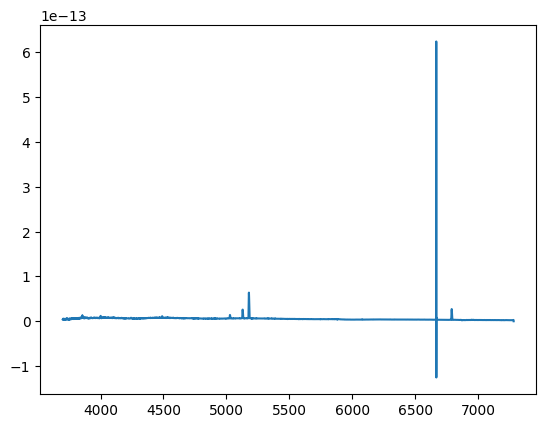

In [9]:
mask = df["#wl"] > 3700.
plt.plot(df[mask]["#wl"], df[mask]["flux"])

In [10]:
mask = (df["#wl"] > 4000.)
outpath = path.parent / f"{path.with_suffix(".txt").name}"
print(f"Saving to {outpath}")
df[mask].to_csv(outpath, sep=" ", index=False)

# For SNID
mask = (df["flux"] > 0) & (df["#wl"] > 3700.)
outpath = path.parent / f"clean_{path.with_suffix(".txt").name}"
print(f"Saving to {outpath}")
df[mask].to_csv(outpath, sep=" ", index=False)

Saving to /Users/rdstein/Data/gmos_sn2026gzf/20260330/S20260330S0020_1D.txt
Saving to /Users/rdstein/Data/gmos_sn2026gzf/20260330/clean_S20260330S0020_1D.txt


In [12]:
names = get_skyportal_names(coord.ra.deg, coord.dec.deg)
names

['2018mtl', '2026gzf', 'ZTF26aaonmha']

In [13]:
if send_to_fritz:

    for name in names:
        print(name)

        text = df.to_string()
        string_buffer = StringIO()

        df.to_csv(string_buffer, index=False)
        text = string_buffer.getvalue()

        filename = ascii_path.name

        payload = {
            "wave_column": 0,
            "flux_column": 1,
            "observed_at": f"{header['DATE']}T{header['UT']}",
            "obj_id": name,
            "instrument_id": instrument_id,
            "ascii": text,
            "filename": path.name,
            "group_ids": [1]
        }

        client = SkyportalClient()
        client.set_up_session()

        res = client.api(
            "GET",
            f"sources/{name}/spectra",
        )
        existing_spectra = res.json()["data"]["spectra"]
        filenames = [x["original_file_filename"] for x in existing_spectra]

        if path.name in filenames:
            print(f"Spectrum {filename} already uploaded.")
        else:
            print(f"Uploading spectrum {filename}.")
            res = client.api(
                "POST",
                "spectra/ascii",
                data=payload
            )
            res.raise_for_status()
        # res = client.api(
        #     "PUT",
        #     "photometry",
        #     data=payload
        # )
        # print(res.json())
        # res.raise_for_status()

2018mtl
Uploading spectrum S20260330S0020_1D_001.dat.
2026gzf
Uploading spectrum S20260330S0020_1D_001.dat.
ZTF26aaonmha
Uploading spectrum S20260330S0020_1D_001.dat.
